In [1]:
import networkx as nx
import itertools
import random
import numpy as np
import subprocess
import pandas as pd
import os
import matplotlib.pyplot as plt
import shutil
import csv
from collections import defaultdict

import sys
sys.path.append("SDTED/")

from SDTED_utilities import *
from main import SDTED

In [2]:
def generar_grafos_no_dirigidos_aleatorios_nx(nodos, num_grafos):
    """
    Genera aleatoriamente una cantidad especificada de grafos no dirigidos
    diferentes usando NetworkX para un número dado de nodos.

    Args:
        nodos: Un entero que representa el número de nodos en el grafo.
        num_grafos: Un entero que especifica la cantidad de grafos aleatorios
                    diferentes a generar.

    Returns:
        Una lista de objetos Graph de NetworkX, donde cada objeto representa
        un grafo no dirigido aleatorio y único.
        Devuelve una lista vacía si num_grafos es inválido.
    """
    if not isinstance(nodos, int) or nodos < 0:
        raise ValueError("El número de nodos debe ser un entero no negativo.")
    if not isinstance(num_grafos, int) or num_grafos <= 0:
        print("La cantidad de grafos a generar debe ser un entero positivo.")
        return []

    nodos_lista = list(range(nodos))
    nodos_lista = [str(i) for i in nodos_lista]
    todos_los_grafos_generados = set()
    grafos_aleatorios = []
    num_posibles_aristas = len(list(itertools.combinations(nodos_lista, 2)))
    max_posibles_grafos = 2**num_posibles_aristas

    if num_grafos > max_posibles_grafos:
        print(f"Advertencia: Se solicitaron {num_grafos} grafos, pero solo hay {max_posibles_grafos} grafos no dirigidos posibles con {nodos} nodos.")
        num_grafos = max_posibles_grafos

    node_shapes = ["ellipse", "rectangle", "diamond"]
    edge_actions = ["create", "read", "open", "connect", "send", "receive", "write", "execute"]

    while len(grafos_aleatorios) < num_grafos:
        grafo_aleatorio = nx.Graph()
        grafo_aleatorio.add_nodes_from(nodos_lista)

        # Asignar atributo 'shape' aleatorio a cada nodo
        for node in grafo_aleatorio.nodes():
            grafo_aleatorio.nodes[node]['shape'] = random.choice(node_shapes)

        aristas_presentes = []
        for u, v in itertools.combinations(nodos_lista, 2):
            if random.random() < 0.5:
                aristas_presentes.append((u, v))

        grafo_aleatorio.add_edges_from(aristas_presentes)

        # Asignar atributo 'action' aleatorio a cada arista presente
        for u, v in grafo_aleatorio.edges():
            grafo_aleatorio.edges[u, v]['action'] = random.choice(edge_actions)

        # Convertir el grafo a una representación hashable (incluyendo atributos)
        nodos_con_atributos = tuple(sorted((n, grafo_aleatorio.nodes[n].get('shape')) for n in grafo_aleatorio.nodes()))
        aristas_con_atributos = tuple(sorted((tuple(sorted(e)), grafo_aleatorio.edges[e].get('action')) for e in grafo_aleatorio.edges()))
        grafo_tuple = (nodos_con_atributos, aristas_con_atributos)

        if grafo_tuple not in todos_los_grafos_generados:
            todos_los_grafos_generados.add(grafo_tuple)
            grafos_aleatorios.append(grafo_aleatorio)

    return grafos_aleatorios

In [44]:
array_num_nodos = [10]
NUM_GRAFOS_GENERADOS = 10
array_grafos_posibles = []
for num_nodos in array_num_nodos:
    grafos_posibles_no_dirigidos_nx = generar_grafos_no_dirigidos_aleatorios_nx(num_nodos, NUM_GRAFOS_GENERADOS)
    print(f"Se generaron {len(grafos_posibles_no_dirigidos_nx)} grafos no dirigidos posibles con {num_nodos} nodos (usando NetworkX):")
    array_grafos_posibles.append(grafos_posibles_no_dirigidos_nx)

Se generaron 10 grafos no dirigidos posibles con 10 nodos (usando NetworkX):


In [55]:
MUTATIONS_CALCULATE = [1,2,4,6,8,10]
NUM_GRAPHS = 200
arr_mutations = [delete_random_node, delete_random_edge, change_direction_edge, add_random_node, add_random_edge]

arr_grafos = []
for index, grafo in enumerate(grafos_posibles_no_dirigidos_nx):
    print(index)
    arr_mut_metrics = []
    G_base = grafo.copy()
    for num_mutations in MUTATIONS_CALCULATE:
        arr_g_candidate = []
        arr_precs = []
        arr_recalls = []
        arr_f1s = []

        arr_g_candidate.append(G_base)
        for graph in range(NUM_GRAPHS):
            G_candidate = G_base.copy()
            G_muted, log_mutations = mute_graph(G_candidate, arr_mutations, num_mutations)
            folder_path = "graphs/" + NAME_DS + '/' + str(num_mutations) + '/'
            if not os.path.exists(folder_path):
                os.makedirs(folder_path)
            nx.write_gexf(G_muted, folder_path + 'G_' + str(graph + 1) + ".gexf")
            with open(folder_path + 'G_' + str(graph + 1) + ".log", 'w') as f: 
                for string in log_mutations:
                    f.write(string + '\n') 
            arr_precs.append(calc_precision(G_base, G_muted))
            arr_recalls.append(calc_recall(G_base, G_muted))
            arr_f1s.append(calc_f1_score(G_base, G_muted))
            arr_g_candidate.append(G_muted)

        arr_g_candidate.append(nx.DiGraph())

        write_SDTED_graphs(arr_g_candidate)
        SDTED("SDTED/Data/CUSTOM")

        df = pd.read_csv("Distance_Matrix.csv", nrows=1)
        shutil.copy2("Distance_Matrix.csv", "graphs/" + NAME_DS + '/' + str(num_mutations) + '/' + 'distance_matrix_'+ str(NUM_GRAPHS) + '.csv')  

        arr_SDTED = df.values.tolist()[0][1:]  # [0] gets the first (and only) row
        arr_SDTED = [1 - min(x / arr_SDTED[-1], 1) for x in arr_SDTED][1:][:-1]
        arr_metrics = [arr_precs, arr_recalls, arr_f1s, arr_SDTED]
        
        num_filas = max(len(arr) for arr in arr_metrics)

        trasp_metrics = []
        for i in range(num_filas):
            fila = [arr[i] if i < len(arr) else "" for arr in arr_metrics]
            trasp_metrics.append(fila)

        with open("graphs/" + NAME_DS + '/' + str(num_mutations) + '/metrics_' + str(NUM_GRAPHS) + '.csv' , "w", newline='') as file:
            writer = csv.writer(file)
            writer.writerow(["Precision", "Recall", "F1-score", "SDTED"])
            for array in trasp_metrics:
                writer.writerow(array)

        arr_mut_metrics.append(arr_metrics)
    arr_grafos.append(arr_mut_metrics)


0
1
2
3
4
5
6
7
8
9


In [62]:
import json

with open("arr_graph" + str(array_num_nodos[0]) + '_' + str(NUM_GRAPHS) + ".json", "w") as f:
    json.dump(arr_grafos, f)

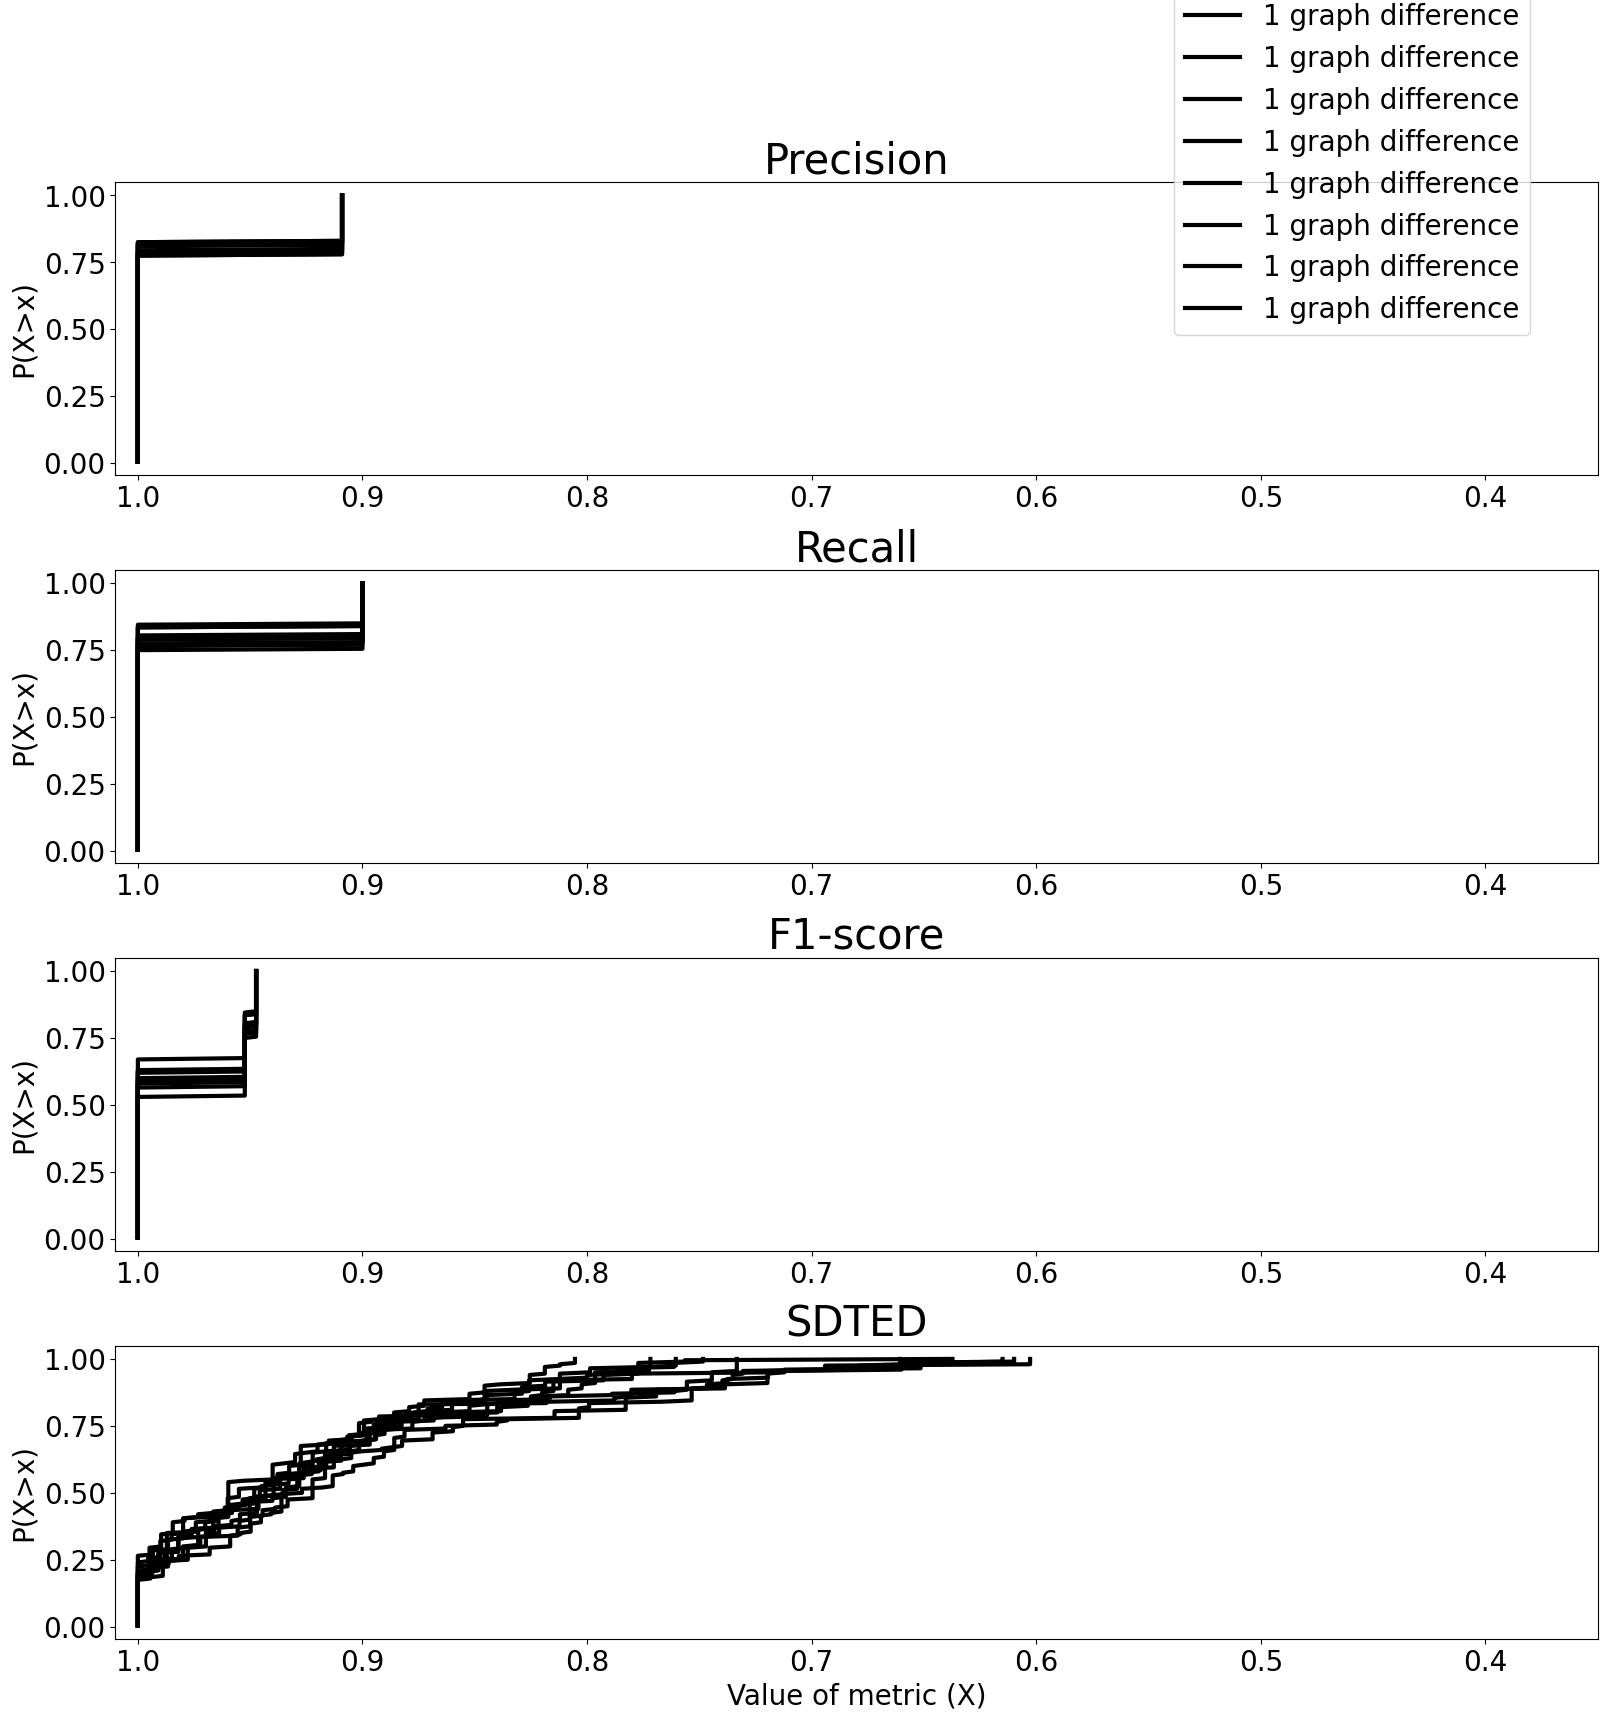

Numero de valores diferentes en el set 0 : 2
Numero de valores diferentes en el set 1 : 2
Numero de valores diferentes en el set 2 : 3
Numero de valores diferentes en el set 3 : 260


In [63]:
array_sets = [set(), set(), set(), set()]
CAMBIO_ACTUAL = 0
plt.style.use('default')
fig, axs = plt.subplots(4)
fig.set_size_inches(16, 16)

axs[0].set_title("Precision", fontsize=30)

axs[1].set_title("Recall", fontsize=30)

axs[2].set_title("F1-score", fontsize=30)

axs[3].set_title("SDTED", fontsize=30)
axs[3].set_xlabel("Value of metric (X)", fontsize=20)

for ax in axs:
    ax.set_ylabel("P(X>x)", fontsize=20)

for ax in axs:
    ax.invert_xaxis()
    ax.set_xlim(1.01, 0.35)
    ax.tick_params(labelsize=20)

for arr_mut_metrics in arr_grafos:

    for num_mutations, metrics_num_mut in enumerate(arr_mut_metrics[CAMBIO_ACTUAL:CAMBIO_ACTUAL+1]):
        for index, metric in enumerate(metrics_num_mut):
            met_sorted = np.sort(metric)[::-1]
            cdf = np.arange(1, len(met_sorted) + 1) / len(met_sorted)
            for elem in met_sorted:
                array_sets[index].add(elem)
            if num_mutations == 0:
                axs[index].plot(met_sorted, cdf, label=f"{MUTATIONS_CALCULATE[CAMBIO_ACTUAL]} graph difference" if index == 0 else "_nolegend_", alpha=1, linewidth=3, color="black")
            else:
                axs[index].plot(met_sorted, cdf, label=f"{num_mutations*5} graph differences" if index == 0 else "_nolegend_", alpha=1, linewidth=3, color="black")
            
fig.legend(loc=(0.73,0.805), prop={'size': 20})
fig.tight_layout()
plt.show()
for index, set_values in enumerate(array_sets):
    print("Numero de valores diferentes en el set", index, ':', len(set_values))
    #fig.savefig("plots/" + name_graph + "_CDF_" + str(NUM_GRAPHS) + '_' + str(MAX_GRAPH_DIFFERENCES) + '.png')


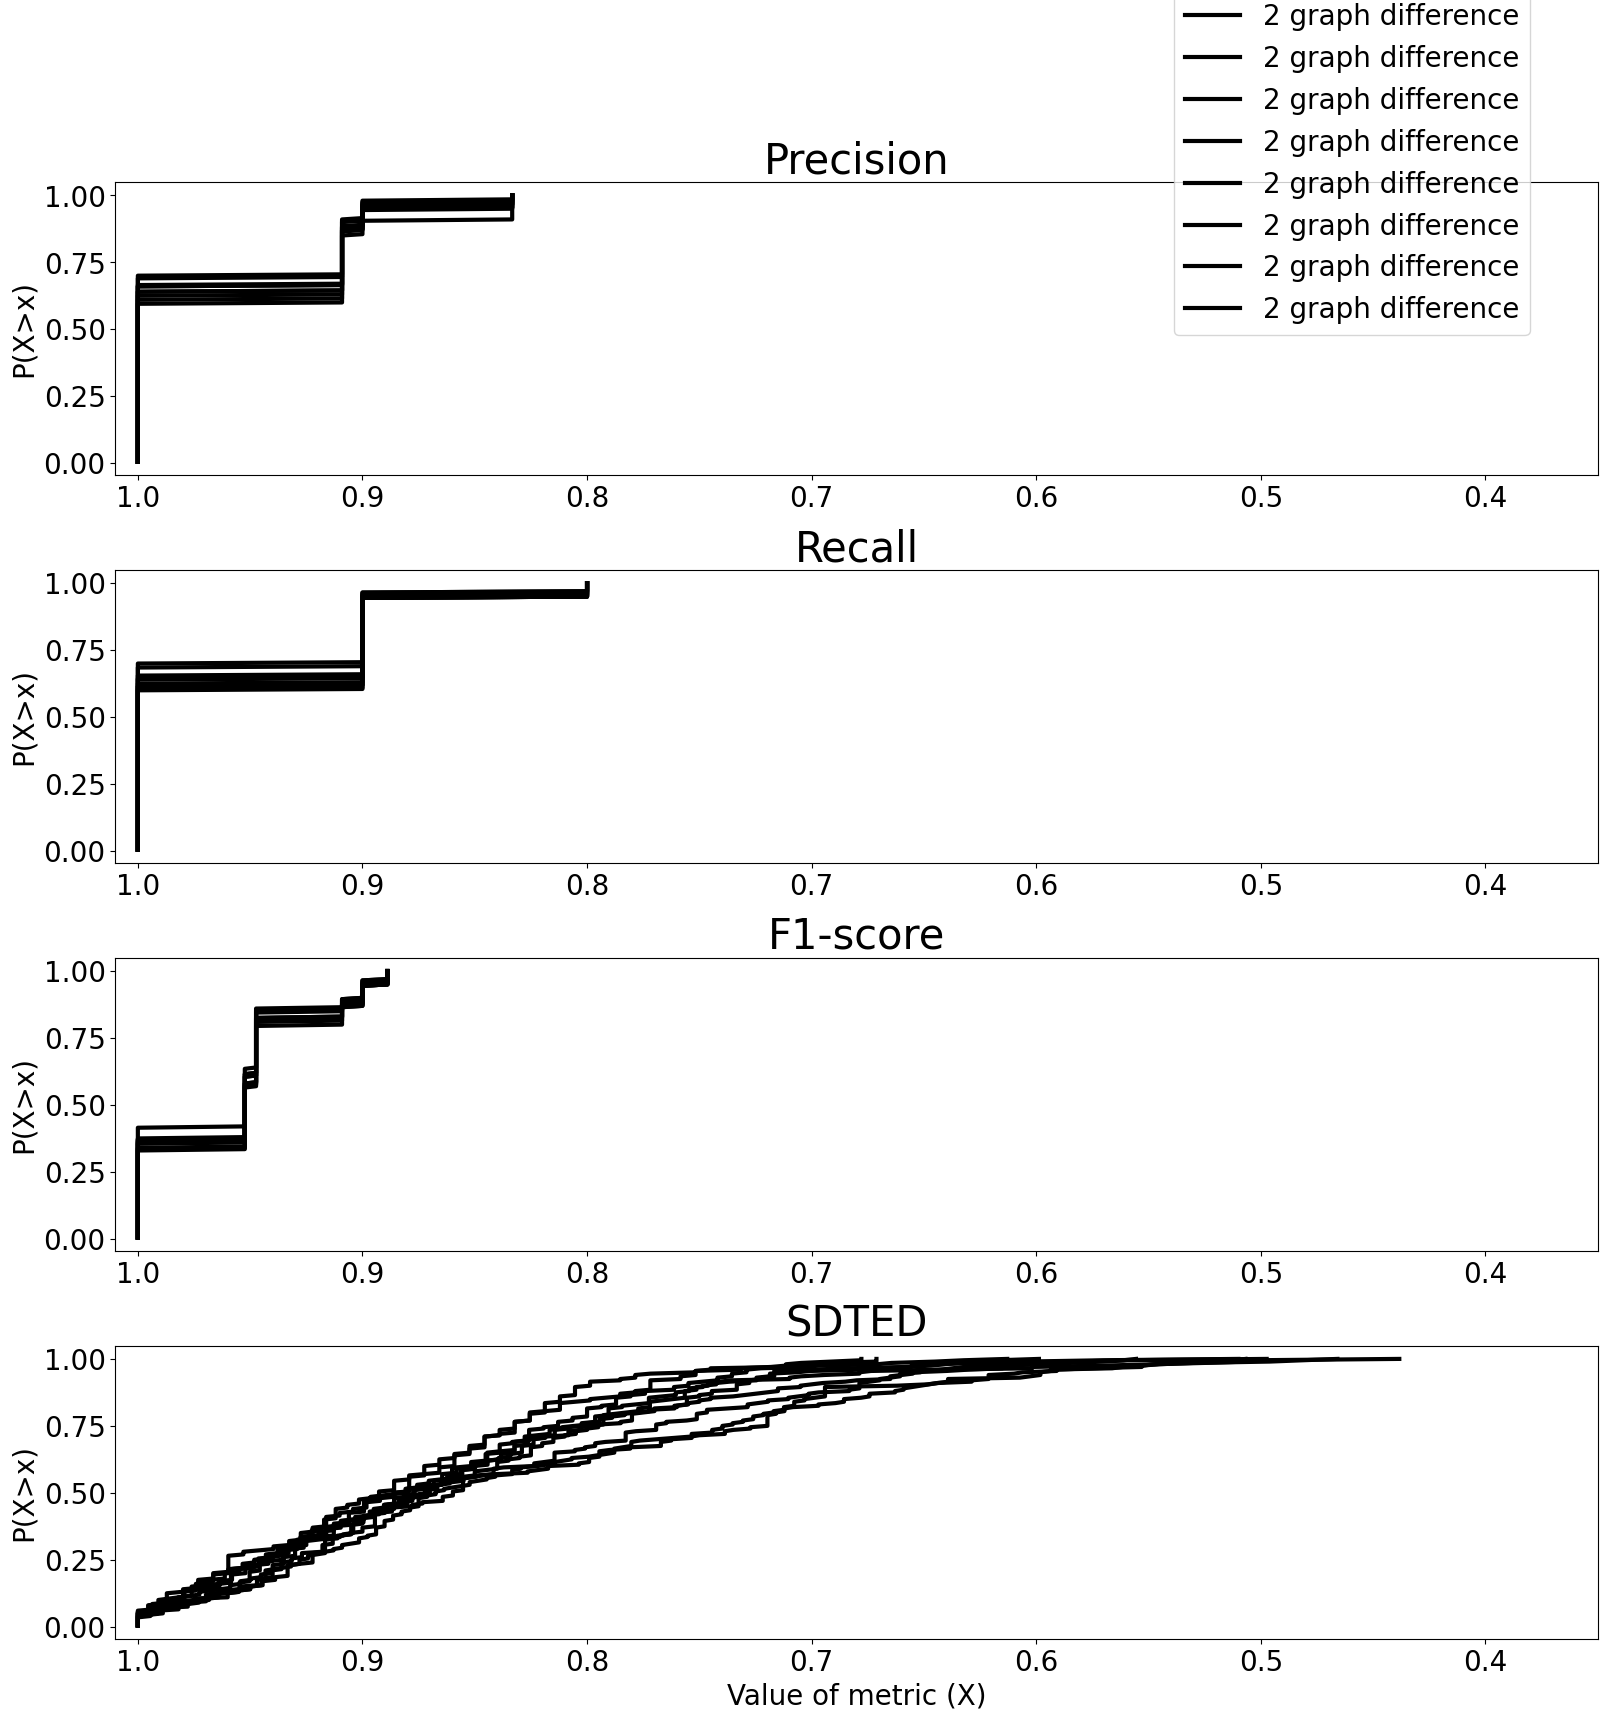

Numero de valores diferentes en el set 0 : 4
Numero de valores diferentes en el set 1 : 3
Numero de valores diferentes en el set 2 : 6
Numero de valores diferentes en el set 3 : 549


In [64]:
array_sets = [set(), set(), set(), set()]
CAMBIO_ACTUAL = 1
plt.style.use('default')
fig, axs = plt.subplots(4)
fig.set_size_inches(16, 16)

axs[0].set_title("Precision", fontsize=30)

axs[1].set_title("Recall", fontsize=30)

axs[2].set_title("F1-score", fontsize=30)

axs[3].set_title("SDTED", fontsize=30)
axs[3].set_xlabel("Value of metric (X)", fontsize=20)

for ax in axs:
    ax.set_ylabel("P(X>x)", fontsize=20)

for ax in axs:
    ax.invert_xaxis()
    ax.set_xlim(1.01, 0.35)
    ax.tick_params(labelsize=20)

for arr_mut_metrics in arr_grafos:

    for num_mutations, metrics_num_mut in enumerate(arr_mut_metrics[CAMBIO_ACTUAL:CAMBIO_ACTUAL+1]):
        for index, metric in enumerate(metrics_num_mut):
            met_sorted = np.sort(metric)[::-1]
            cdf = np.arange(1, len(met_sorted) + 1) / len(met_sorted)
            for elem in met_sorted:
                array_sets[index].add(elem)
            if num_mutations == 0:
                axs[index].plot(met_sorted, cdf, label=f"{MUTATIONS_CALCULATE[CAMBIO_ACTUAL]} graph difference" if index == 0 else "_nolegend_", alpha=1, linewidth=3, color="black")
            else:
                axs[index].plot(met_sorted, cdf, label=f"{num_mutations*5} graph differences" if index == 0 else "_nolegend_", alpha=1, linewidth=3, color="black")
            
fig.legend(loc=(0.73,0.805), prop={'size': 20})
fig.tight_layout()
plt.show()
for index, set_values in enumerate(array_sets):
    print("Numero de valores diferentes en el set", index, ':', len(set_values))
    #fig.savefig("plots/" + name_graph + "_CDF_" + str(NUM_GRAPHS) + '_' + str(MAX_GRAPH_DIFFERENCES) + '.png')


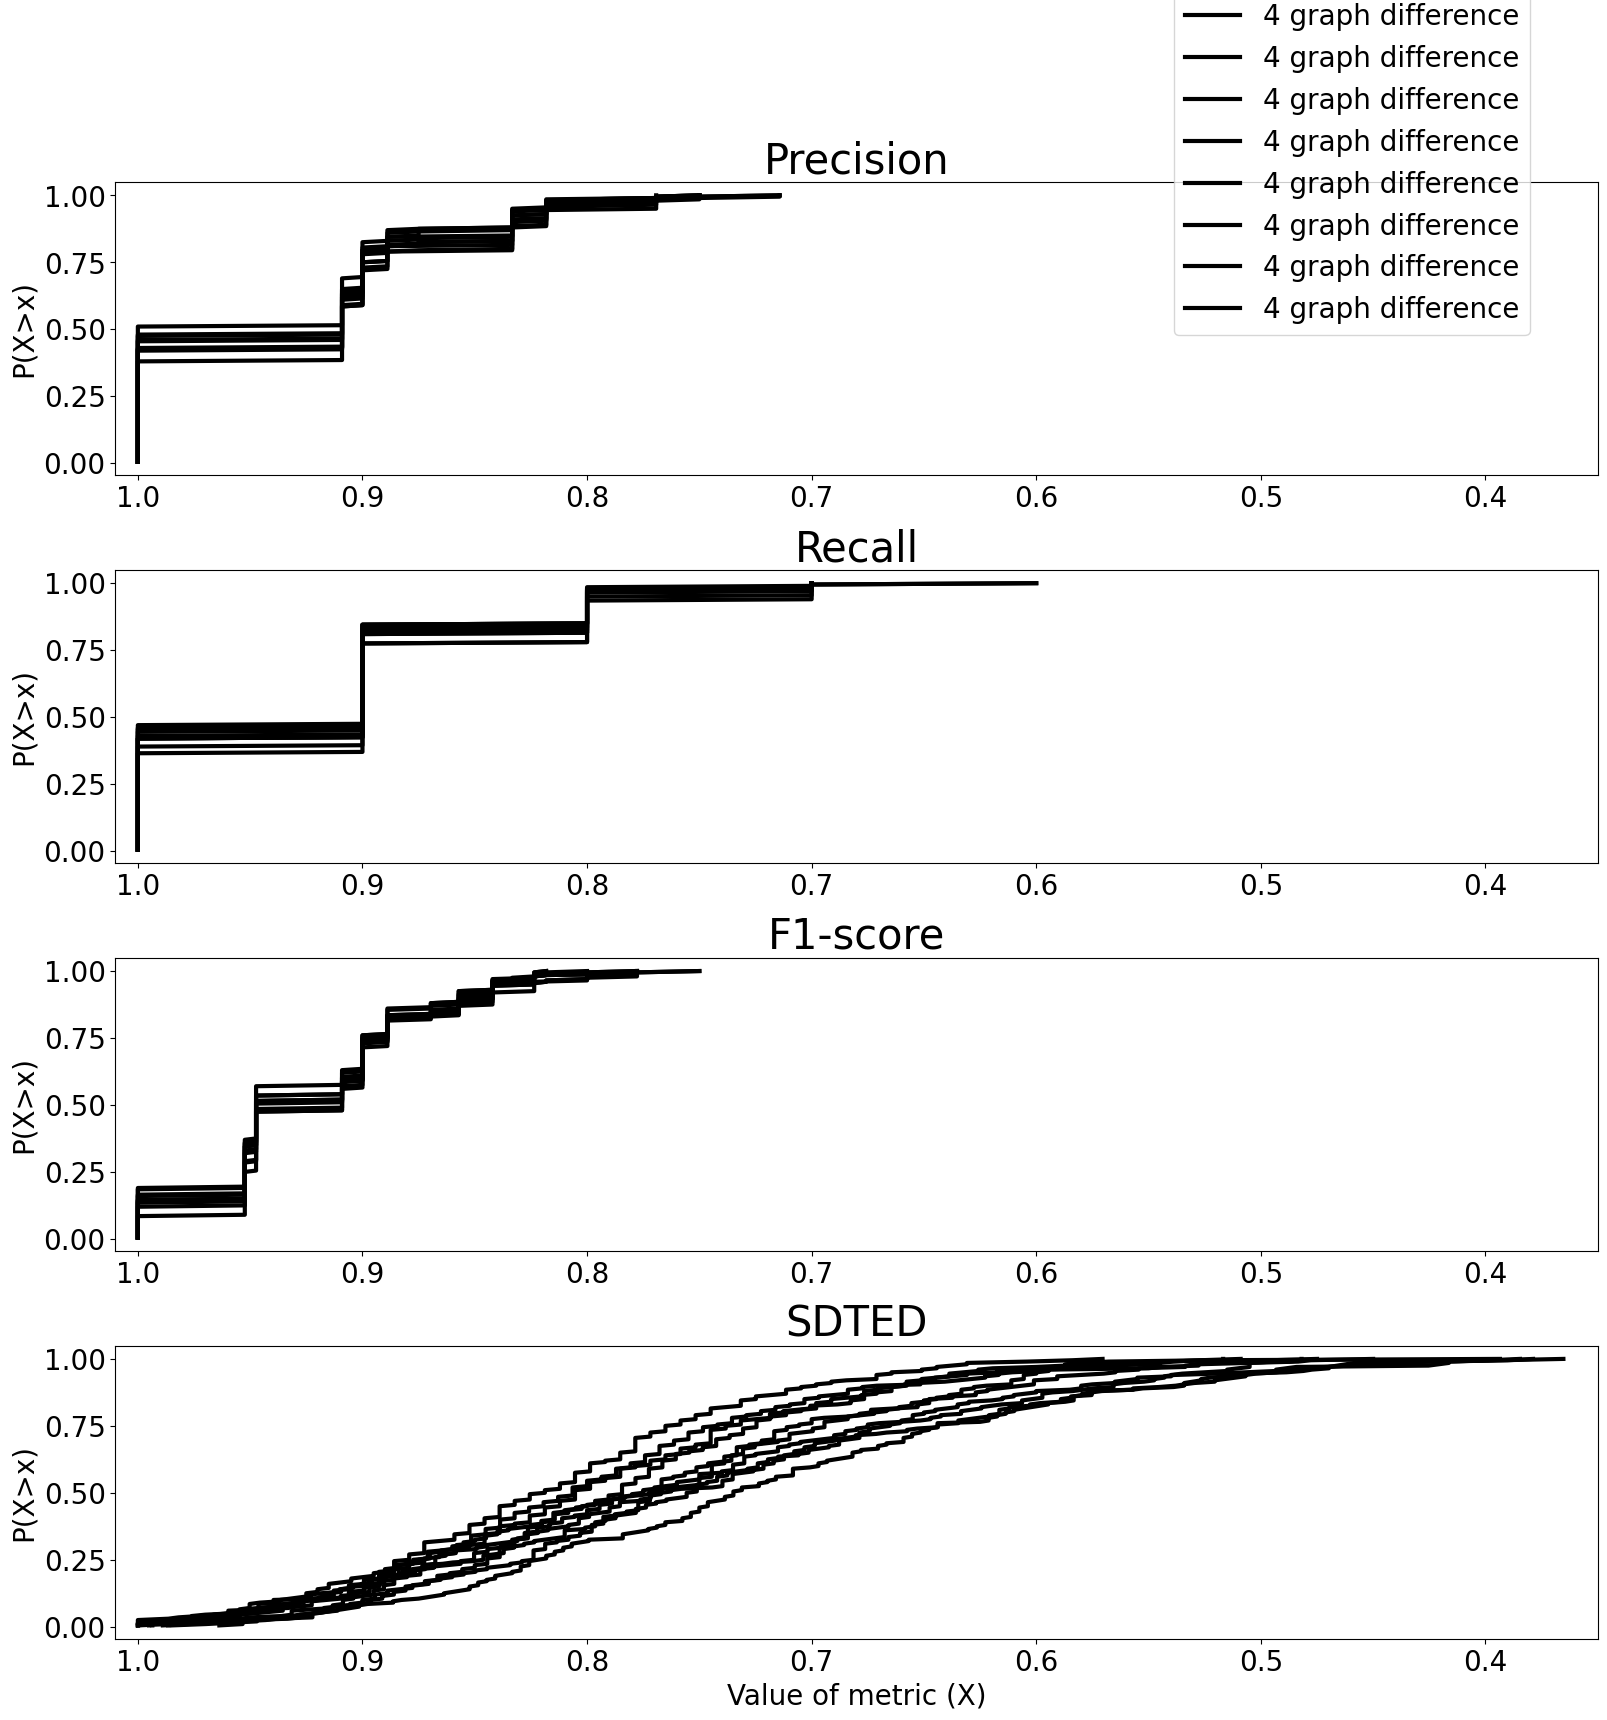

Numero de valores diferentes en el set 0 : 11
Numero de valores diferentes en el set 1 : 5
Numero de valores diferentes en el set 2 : 15
Numero de valores diferentes en el set 3 : 702


In [65]:
array_sets = [set(), set(), set(), set()]
CAMBIO_ACTUAL = 2
plt.style.use('default')
fig, axs = plt.subplots(4)
fig.set_size_inches(16, 16)

axs[0].set_title("Precision", fontsize=30)

axs[1].set_title("Recall", fontsize=30)

axs[2].set_title("F1-score", fontsize=30)

axs[3].set_title("SDTED", fontsize=30)
axs[3].set_xlabel("Value of metric (X)", fontsize=20)

for ax in axs:
    ax.set_ylabel("P(X>x)", fontsize=20)

for ax in axs:
    ax.invert_xaxis()
    ax.set_xlim(1.01, 0.35)
    ax.tick_params(labelsize=20)

for arr_mut_metrics in arr_grafos:

    for num_mutations, metrics_num_mut in enumerate(arr_mut_metrics[CAMBIO_ACTUAL:CAMBIO_ACTUAL+1]):
        for index, metric in enumerate(metrics_num_mut):
            met_sorted = np.sort(metric)[::-1]
            cdf = np.arange(1, len(met_sorted) + 1) / len(met_sorted)
            for elem in met_sorted:
                array_sets[index].add(elem)
            if num_mutations == 0:
                axs[index].plot(met_sorted, cdf, label=f"{MUTATIONS_CALCULATE[CAMBIO_ACTUAL]} graph difference" if index == 0 else "_nolegend_", alpha=1, linewidth=3, color="black")
            else:
                axs[index].plot(met_sorted, cdf, label=f"{num_mutations*5} graph differences" if index == 0 else "_nolegend_", alpha=1, linewidth=3, color="black")
            
fig.legend(loc=(0.73,0.805), prop={'size': 20})
fig.tight_layout()
plt.show()
for index, set_values in enumerate(array_sets):
    print("Numero de valores diferentes en el set", index, ':', len(set_values))
    #fig.savefig("plots/" + name_graph + "_CDF_" + str(NUM_GRAPHS) + '_' + str(MAX_GRAPH_DIFFERENCES) + '.png')


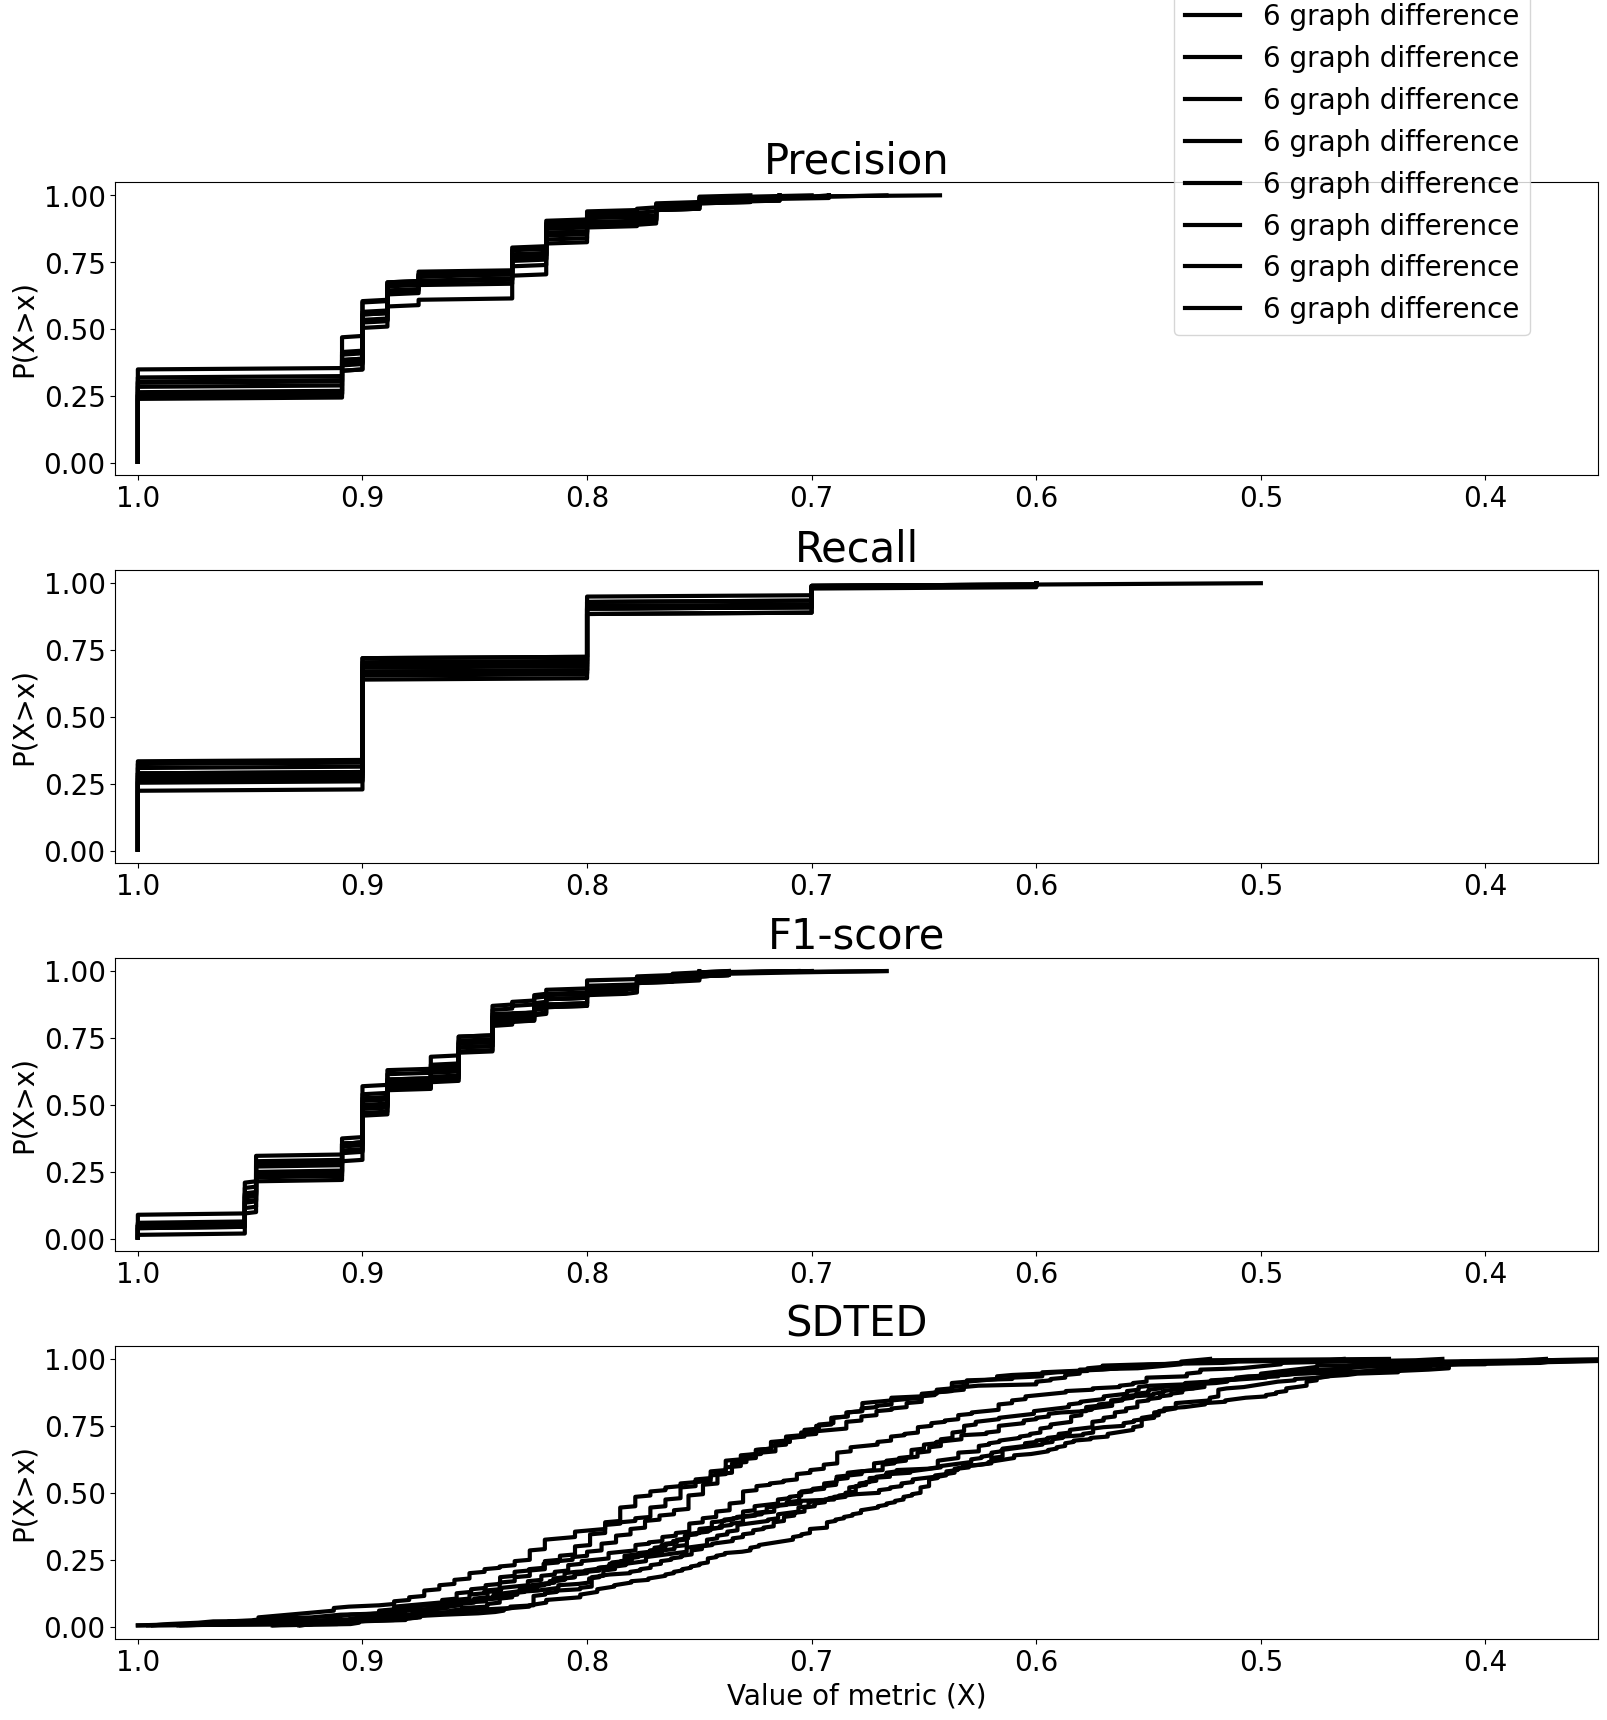

Numero de valores diferentes en el set 0 : 18
Numero de valores diferentes en el set 1 : 6
Numero de valores diferentes en el set 2 : 24
Numero de valores diferentes en el set 3 : 721


In [66]:
array_sets = [set(), set(), set(), set()]
CAMBIO_ACTUAL = 3
plt.style.use('default')
fig, axs = plt.subplots(4)
fig.set_size_inches(16, 16)

axs[0].set_title("Precision", fontsize=30)

axs[1].set_title("Recall", fontsize=30)

axs[2].set_title("F1-score", fontsize=30)

axs[3].set_title("SDTED", fontsize=30)
axs[3].set_xlabel("Value of metric (X)", fontsize=20)

for ax in axs:
    ax.set_ylabel("P(X>x)", fontsize=20)

for ax in axs:
    ax.invert_xaxis()
    ax.set_xlim(1.01, 0.35)
    ax.tick_params(labelsize=20)

for arr_mut_metrics in arr_grafos:

    for num_mutations, metrics_num_mut in enumerate(arr_mut_metrics[CAMBIO_ACTUAL:CAMBIO_ACTUAL+1]):
        for index, metric in enumerate(metrics_num_mut):
            met_sorted = np.sort(metric)[::-1]
            cdf = np.arange(1, len(met_sorted) + 1) / len(met_sorted)
            for elem in met_sorted:
                array_sets[index].add(elem)
            if num_mutations == 0:
                axs[index].plot(met_sorted, cdf, label=f"{MUTATIONS_CALCULATE[CAMBIO_ACTUAL]} graph difference" if index == 0 else "_nolegend_", alpha=1, linewidth=3, color="black")
            else:
                axs[index].plot(met_sorted, cdf, label=f"{num_mutations*5} graph differences" if index == 0 else "_nolegend_", alpha=1, linewidth=3, color="black")
            
fig.legend(loc=(0.73,0.805), prop={'size': 20})
fig.tight_layout()
plt.show()
for index, set_values in enumerate(array_sets):
    print("Numero de valores diferentes en el set", index, ':', len(set_values))
    #fig.savefig("plots/" + name_graph + "_CDF_" + str(NUM_GRAPHS) + '_' + str(MAX_GRAPH_DIFFERENCES) + '.png')


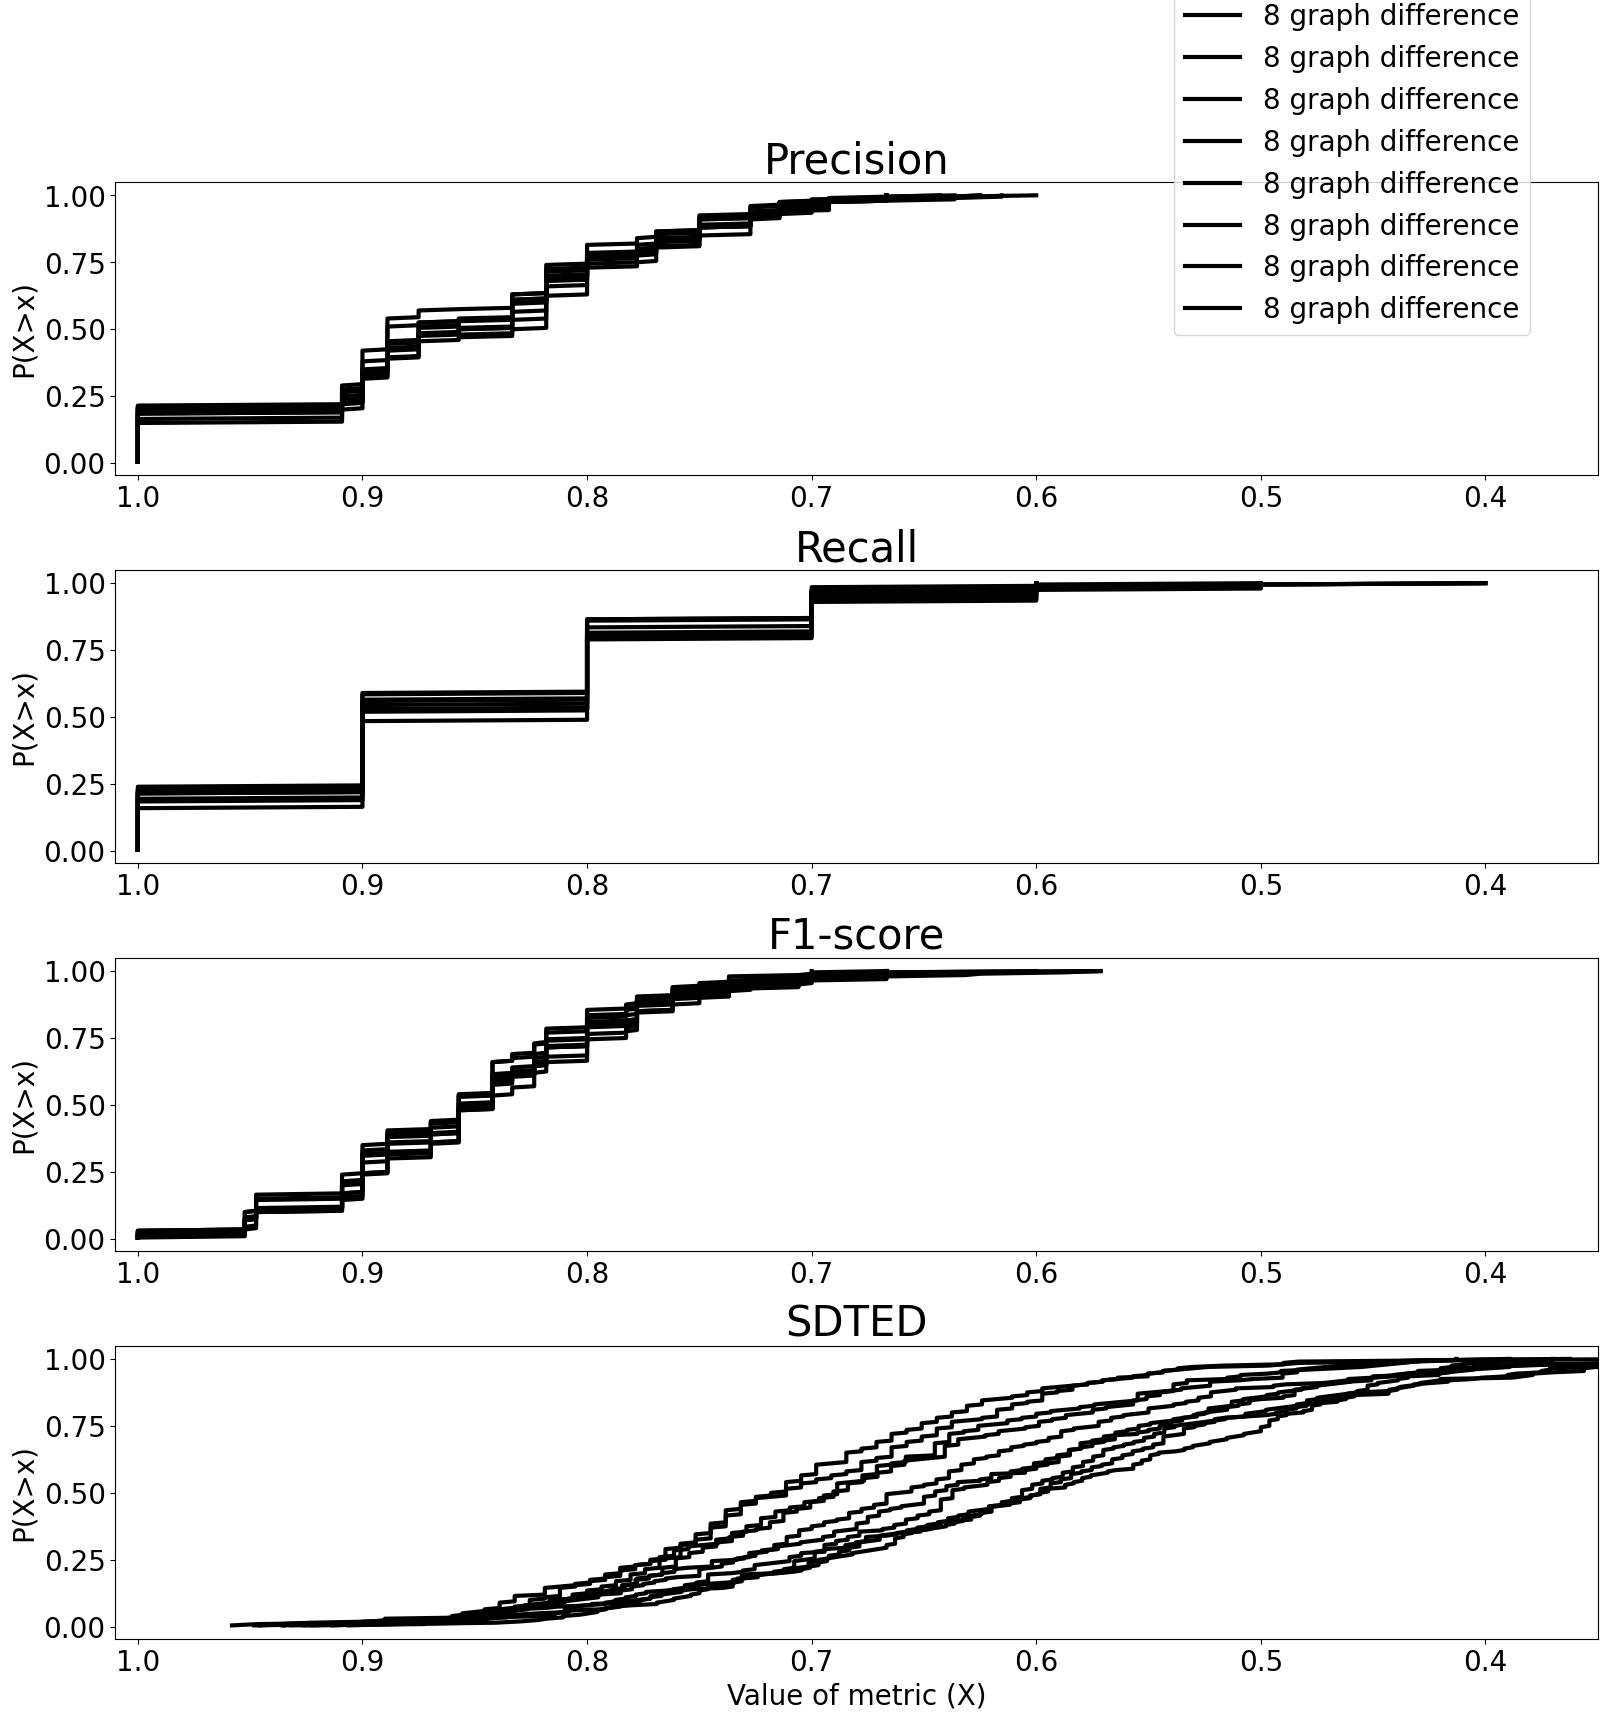

Numero de valores diferentes en el set 0 : 22
Numero de valores diferentes en el set 1 : 7
Numero de valores diferentes en el set 2 : 32
Numero de valores diferentes en el set 3 : 733


In [67]:
array_sets = [set(), set(), set(), set()]
array_metrics_violin = [[], [], [], []]
CAMBIO_ACTUAL = 4
plt.style.use('default')
fig, axs = plt.subplots(4)
fig.set_size_inches(16, 16)

axs[0].set_title("Precision", fontsize=30)

axs[1].set_title("Recall", fontsize=30)

axs[2].set_title("F1-score", fontsize=30)

axs[3].set_title("SDTED", fontsize=30)
axs[3].set_xlabel("Value of metric (X)", fontsize=20)

for ax in axs:
    ax.set_ylabel("P(X>x)", fontsize=20)

for ax in axs:
    ax.invert_xaxis()
    ax.set_xlim(1.01, 0.35)
    ax.tick_params(labelsize=20)

for arr_mut_metrics in arr_grafos:

    for num_mutations, metrics_num_mut in enumerate(arr_mut_metrics[CAMBIO_ACTUAL:CAMBIO_ACTUAL+1]):
        for index, metric in enumerate(metrics_num_mut):
            met_sorted = np.sort(metric)[::-1]
            cdf = np.arange(1, len(met_sorted) + 1) / len(met_sorted)
            for elem in met_sorted:
                array_metrics_violin[index].append(elem)
                array_sets[index].add(elem)
            if num_mutations == 0:
                axs[index].plot(met_sorted, cdf, label=f"{MUTATIONS_CALCULATE[CAMBIO_ACTUAL]} graph difference" if index == 0 else "_nolegend_", alpha=1, linewidth=3, color="black")
            else:
                axs[index].plot(met_sorted, cdf, label=f"{num_mutations*5} graph differences" if index == 0 else "_nolegend_", alpha=1, linewidth=3, color="black")
            
fig.legend(loc=(0.73,0.805), prop={'size': 20})
fig.tight_layout()
plt.show()
for index, set_values in enumerate(array_sets):
    print("Numero de valores diferentes en el set", index, ':', len(set_values))
    #fig.savefig("plots/" + name_graph + "_CDF_" + str(NUM_GRAPHS) + '_' + str(MAX_GRAPH_DIFFERENCES) + '.png')


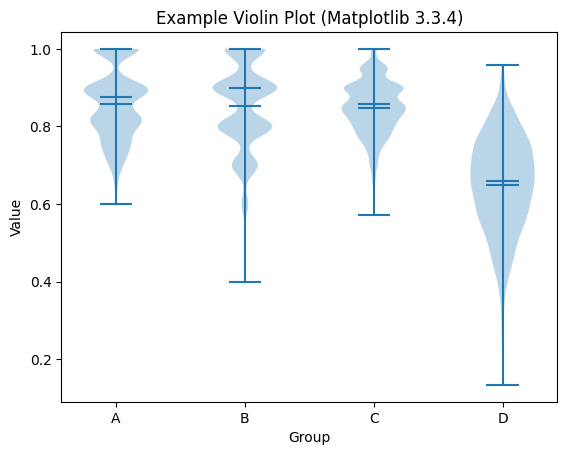

In [68]:
import numpy as np
import matplotlib.pyplot as plt



# 2) Draw the violins
fig, ax = plt.subplots()
ax.violinplot(
    array_metrics_violin,
    showmeans=True,      # horizontal bar for the mean
    showmedians=True,    # horizontal bar for the median
    showextrema=True,     # vertical “whiskers” for min/max
    points = len(array_metrics_violin[0])
)

# 3) Cosmetic touches
ax.set_title("Example Violin Plot (Matplotlib 3.3.4)")
ax.set_xlabel("Group")
ax.set_ylabel("Value")
ax.set_xticks([1, 2, 3, 4])
ax.set_xticklabels(["A", "B", "C", "D"])

plt.show()


9 mayo noche

In [2]:
# We Load DARPA E3 GRAPHS

array_graphs_DARPA = []
for root, dirs, files in os.walk("graphs/DARPA_E3/", topdown=False):
   for index, name in enumerate(files):
      if name.endswith(".gml"):
        G = nx.read_gml(os.path.join(root, name))
        array_graphs_DARPA.append(G)

MUTATIONS_CALCULATE = [1,2,4,6,8,10]
NUM_GRAPHS = 250
arr_mutations = [delete_random_node, delete_random_edge, change_direction_edge, add_random_node, add_random_edge]

arr_grafos = []
for index, grafo in enumerate(array_graphs_DARPA[:]):
    print("Processing graph number", index + 1)
    arr_mut_metrics = []
    G_base = grafo.copy()
    for num_mutations in MUTATIONS_CALCULATE:
        arr_g_candidate = []
        arr_precs = []
        arr_recalls = []
        arr_f1s = []

        arr_g_candidate.append(G_base)
        for graph in range(NUM_GRAPHS):
            G_candidate = G_base.copy()
            G_muted, log_mutations = mute_graph(G_candidate, arr_mutations, num_mutations)
            folder_path = "graphs/" + NAME_DS + '/' + str(num_mutations) + '/'
            if not os.path.exists(folder_path):
                os.makedirs(folder_path)
            nx.write_gexf(G_muted, folder_path + 'G_' + str(graph + 1) + ".gexf")
            with open(folder_path + 'G_' + str(graph + 1) + ".log", 'w') as f: 
                for string in log_mutations:
                    f.write(string + '\n') 
            arr_precs.append(calc_precision(G_base, G_muted))
            arr_recalls.append(calc_recall(G_base, G_muted))
            arr_f1s.append(calc_f1_score(G_base, G_muted))
            arr_g_candidate.append(G_muted)

        arr_g_candidate.append(nx.DiGraph())

        write_SDTED_graphs(arr_g_candidate)
        SDTED("SDTED/Data/CUSTOM")

        df = pd.read_csv("Distance_Matrix.csv", nrows=1)
        shutil.copy2("Distance_Matrix.csv", "graphs/" + NAME_DS + '/' + str(num_mutations) + '/' + 'distance_matrix_'+ str(NUM_GRAPHS) + '.csv')  

        arr_SDTED = df.values.tolist()[0][1:]  # [0] gets the first (and only) row
        arr_SDTED = [1 - min(x / arr_SDTED[-1], 1) for x in arr_SDTED][1:][:-1]
        arr_metrics = [arr_precs, arr_recalls, arr_f1s, arr_SDTED]

        num_filas = max(len(arr) for arr in arr_metrics)

        trasp_metrics = []
        for i in range(num_filas):
            fila = [arr[i] if i < len(arr) else "" for arr in arr_metrics]
            trasp_metrics.append(fila)

        with open("graphs/" + NAME_DS + '/' + str(num_mutations) + '/metrics_' + str(NUM_GRAPHS) + '.csv' , "w", newline='') as file:
            writer = csv.writer(file)
            writer.writerow(["Precision", "Recall", "F1-score", "SDTED"])
            for array in trasp_metrics:
                writer.writerow(array)

        arr_mut_metrics.append(arr_metrics)
    arr_grafos.append(arr_mut_metrics)


Processing graph number 1
Processing graph number 2
Processing graph number 3
Processing graph number 4
Processing graph number 5
Processing graph number 6
Processing graph number 7
Processing graph number 8
Processing graph number 9
Processing graph number 10
Processing graph number 11
Processing graph number 12
Processing graph number 13
Processing graph number 14
Processing graph number 15
Processing graph number 16
Processing graph number 17
Processing graph number 18


In [48]:
import json

with open(f'output_{NUM_GRAPHS}.txt', 'w') as filehandle:
    json.dump(arr_grafos, filehandle)

In [5]:
# Convert to set
METRICS_NAME  = ["Precision", "Recall", "F1-score", "SDTED"]
arr_set_all_merged = {}
for mut in MUTATIONS_CALCULATE:
    arr_set_all_merged[mut] = [set() for metric in METRICS_NAME]
dict_num_values = {}
for index, grafo in enumerate(arr_grafos[:]):
    dict_num_values[index] = {}
    for index_mut, number_mut in enumerate(grafo):
        array_set_mutations = []
        dict_num_values[index][MUTATIONS_CALCULATE[index_mut]] = {}
        for index_j, metric in enumerate(number_mut):
            set_mut_metric =  set()
            for value in metric:
                set_mut_metric.add(value)
                arr_set_all_merged[MUTATIONS_CALCULATE[index_mut]][index_j].add(value)
            array_set_mutations.append(set_mut_metric)
            dict_num_values[index][MUTATIONS_CALCULATE[index_mut]][METRICS_NAME[index_j]] = len(set_mut_metric)


dict_card_mut = {}
for mut in arr_set_all_merged.keys():
    dict_card_mut[mut] = {}
    for index, metric in enumerate(METRICS_NAME):
        dict_card_mut[mut][metric] = len(arr_set_all_merged[mut][index])

In [54]:
dict_num_values

{0: {1: {'Precision': 2, 'Recall': 2, 'F1-score': 3, 'SDTED': 18},
  2: {'Precision': 4, 'Recall': 3, 'F1-score': 6, 'SDTED': 28},
  4: {'Precision': 8, 'Recall': 3, 'F1-score': 10, 'SDTED': 33},
  6: {'Precision': 11, 'Recall': 5, 'F1-score': 14, 'SDTED': 33},
  8: {'Precision': 16, 'Recall': 5, 'F1-score': 19, 'SDTED': 39},
  10: {'Precision': 21, 'Recall': 7, 'F1-score': 26, 'SDTED': 34}},
 1: {1: {'Precision': 2, 'Recall': 2, 'F1-score': 3, 'SDTED': 13},
  2: {'Precision': 4, 'Recall': 3, 'F1-score': 6, 'SDTED': 23},
  4: {'Precision': 7, 'Recall': 4, 'F1-score': 10, 'SDTED': 30},
  6: {'Precision': 11, 'Recall': 4, 'F1-score': 14, 'SDTED': 28},
  8: {'Precision': 16, 'Recall': 5, 'F1-score': 19, 'SDTED': 31},
  10: {'Precision': 16, 'Recall': 5, 'F1-score': 19, 'SDTED': 32}},
 2: {1: {'Precision': 2, 'Recall': 2, 'F1-score': 3, 'SDTED': 7},
  2: {'Precision': 4, 'Recall': 2, 'F1-score': 5, 'SDTED': 15},
  4: {'Precision': 8, 'Recall': 3, 'F1-score': 9, 'SDTED': 26},
  6: {'Precisi

In [52]:
def extraer_max_min(data):
    """
    Recorre un diccionario anidado de la forma:
        {i: {j: {'Precision': …, 'Recall': …, …}}}
    y devuelve:
        {'Maximos': {j: {...}}, 'Minimos': {j: {...}}}
    """
    # averiguamos las claves de segundo nivel y las métricas existentes
    ejemplo_j   = next(iter(next(iter(data.values())).keys()))
    ejemplo_met = next(iter(data[next(iter(data))][ejemplo_j]))
    
    max_min = {'Maximos': defaultdict(dict), 'Minimos': defaultdict(dict), 'Media': defaultdict(dict)}
    
    for j in data[next(iter(data))]:               # 1, 2, 4, 6, 8, 10
        for met in data[next(iter(data))][j]:      # Precision, Recall, …
            valores = [data[i][j][met] for i in data if j in data[i]]
            max_min['Maximos'][j][met] = max(valores)
            max_min['Minimos'][j][met] = min(valores)
            max_min['Media'][j][met] = sum(valores)/len(valores)
    
    # convertir los defaultdict en dict para obtener la salida “limpia”
    return {k: dict(v) for k, v in max_min.items()}

dict_max_min = extraer_max_min(dict_num_values)
dict_max_min

{'Maximos': {1: {'Precision': 2, 'Recall': 2, 'F1-score': 3, 'SDTED': 43},
  2: {'Precision': 4, 'Recall': 3, 'F1-score': 6, 'SDTED': 85},
  4: {'Precision': 11, 'Recall': 5, 'F1-score': 14, 'SDTED': 96},
  6: {'Precision': 17, 'Recall': 6, 'F1-score': 21, 'SDTED': 105},
  8: {'Precision': 24, 'Recall': 7, 'F1-score': 29, 'SDTED': 112},
  10: {'Precision': 28, 'Recall': 7, 'F1-score': 34, 'SDTED': 100}},
 'Minimos': {1: {'Precision': 2, 'Recall': 2, 'F1-score': 3, 'SDTED': 8},
  2: {'Precision': 4, 'Recall': 3, 'F1-score': 6, 'SDTED': 30},
  4: {'Precision': 8, 'Recall': 4, 'F1-score': 11, 'SDTED': 44},
  6: {'Precision': 11, 'Recall': 5, 'F1-score': 17, 'SDTED': 48},
  8: {'Precision': 13, 'Recall': 5, 'F1-score': 20, 'SDTED': 48},
  10: {'Precision': 13, 'Recall': 6, 'F1-score': 22, 'SDTED': 51}},
 'Media': {1: {'Precision': 2.0,
   'Recall': 2.0,
   'F1-score': 3.0,
   'SDTED': 21.88888888888889},
  2: {'Precision': 4.0,
   'Recall': 3.0,
   'F1-score': 6.0,
   'SDTED': 44.611111111

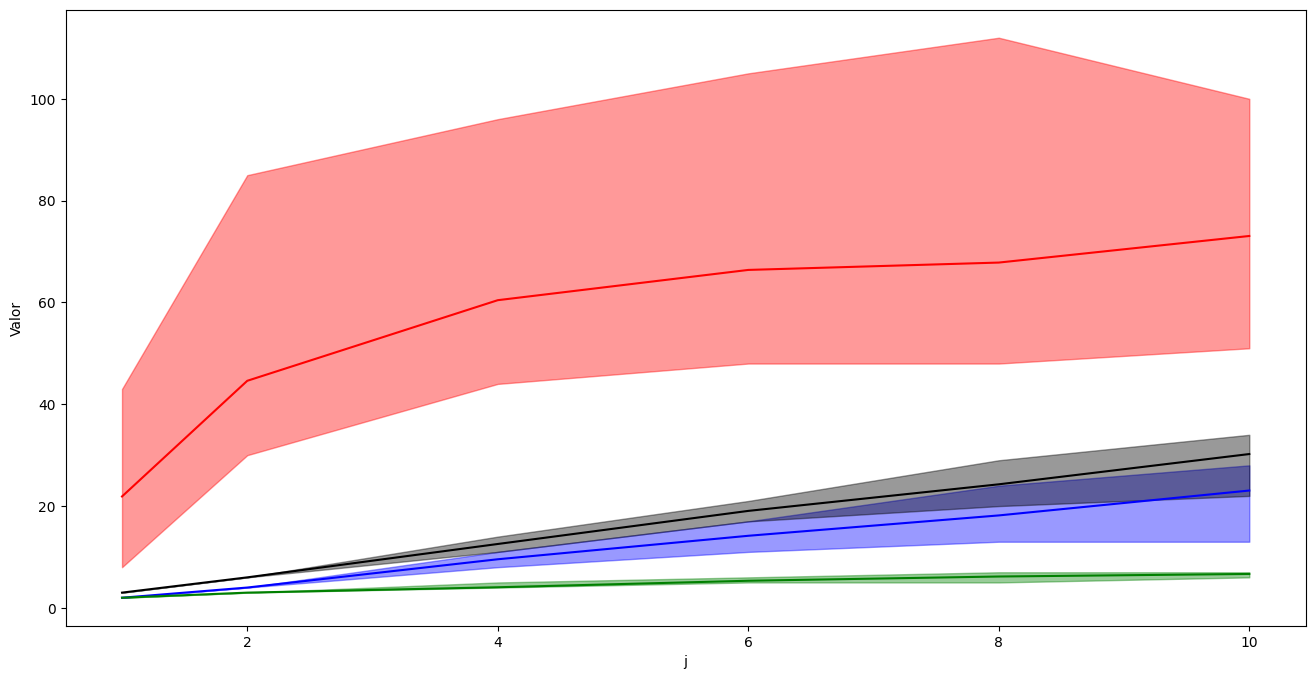

In [56]:

plt.style.use('default')
# ------------------------------------------------------------------
# Ploteo con matplotlib
# ------------------------------------------------------------------
j_vals = sorted(dict_max_min['Maximos'].keys())
metrics = list(dict_max_min['Maximos'][j_vals[0]].keys())

# --- Gráfico de Máximos ---
plt.figure(figsize=(16,8))
colors = ["blue", "green", "black", "red"]
for index, met in enumerate(metrics):
    plt.plot(j_vals,
             [dict_max_min['Media'][j][met]  for j in j_vals],
             label=met,
             color=colors[index])

    plt.fill_between(j_vals, [dict_max_min['Maximos'][j][met] for j in j_vals], [dict_max_min['Minimos'][j][met] for j in j_vals], alpha=0.4, color=colors[index])
#plt.title('Máximos por métrica')
plt.xlabel('j')
plt.ylabel('Valor')

plt.savefig("plots/area_cardinality.png")
plt.show()


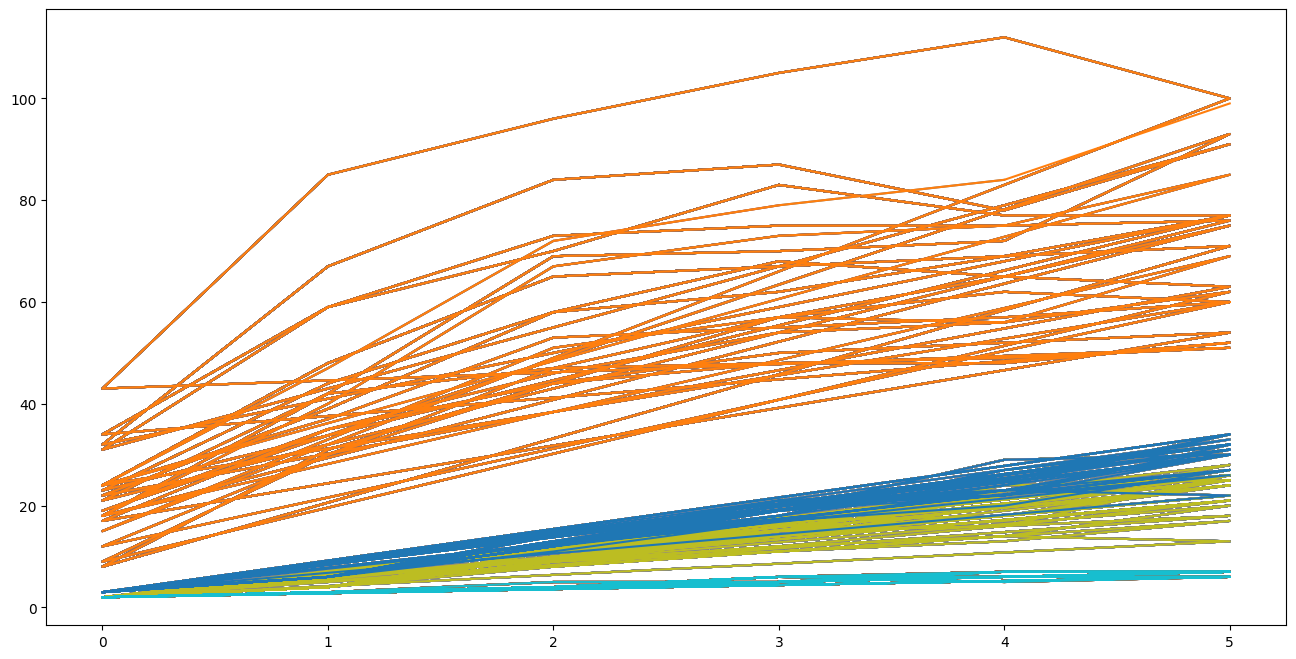

In [50]:
plt.figure(figsize=(16,8))

x_prec = []
y_prec = []
x_rec = []
y_rec = []
x_f1 = []
y_f1 = []
x_sdted = []
y_sdted= []

factor_norm = NUM_GRAPHS*len(dict_num_values.keys())

for graph in dict_num_values.keys():

    for index, mut in enumerate(list(dict_num_values[graph].keys())):
        
        x_prec.append(index)
        x_rec.append(index)
        x_f1.append(index)
        x_sdted.append(index)

        y_prec.append(dict_num_values[graph][mut]["Precision"])
        y_rec.append(dict_num_values[graph][mut]["Recall"])
        y_f1.append(dict_num_values[graph][mut]["F1-score"])
        y_sdted.append(dict_num_values[graph][mut]["SDTED"])

        plt.plot(x_prec, y_prec, label = "Precision", )
        plt.plot(x_rec, y_rec, label = "Recall")
        plt.plot(x_f1, y_f1, label="F1-score")
        plt.plot(x_sdted, y_sdted, label="SDTED")
plt.show()

In [29]:
dict_card_mut

{1: {'Precision': 14, 'Recall': 14, 'F1-score': 20, 'SDTED': 247},
 2: {'Precision': 26, 'Recall': 23, 'F1-score': 39, 'SDTED': 391},
 4: {'Precision': 42, 'Recall': 31, 'F1-score': 69, 'SDTED': 497},
 6: {'Precision': 55, 'Recall': 36, 'F1-score': 97, 'SDTED': 526},
 8: {'Precision': 75, 'Recall': 44, 'F1-score': 133, 'SDTED': 548},
 10: {'Precision': 83, 'Recall': 47, 'F1-score': 146, 'SDTED': 538}}

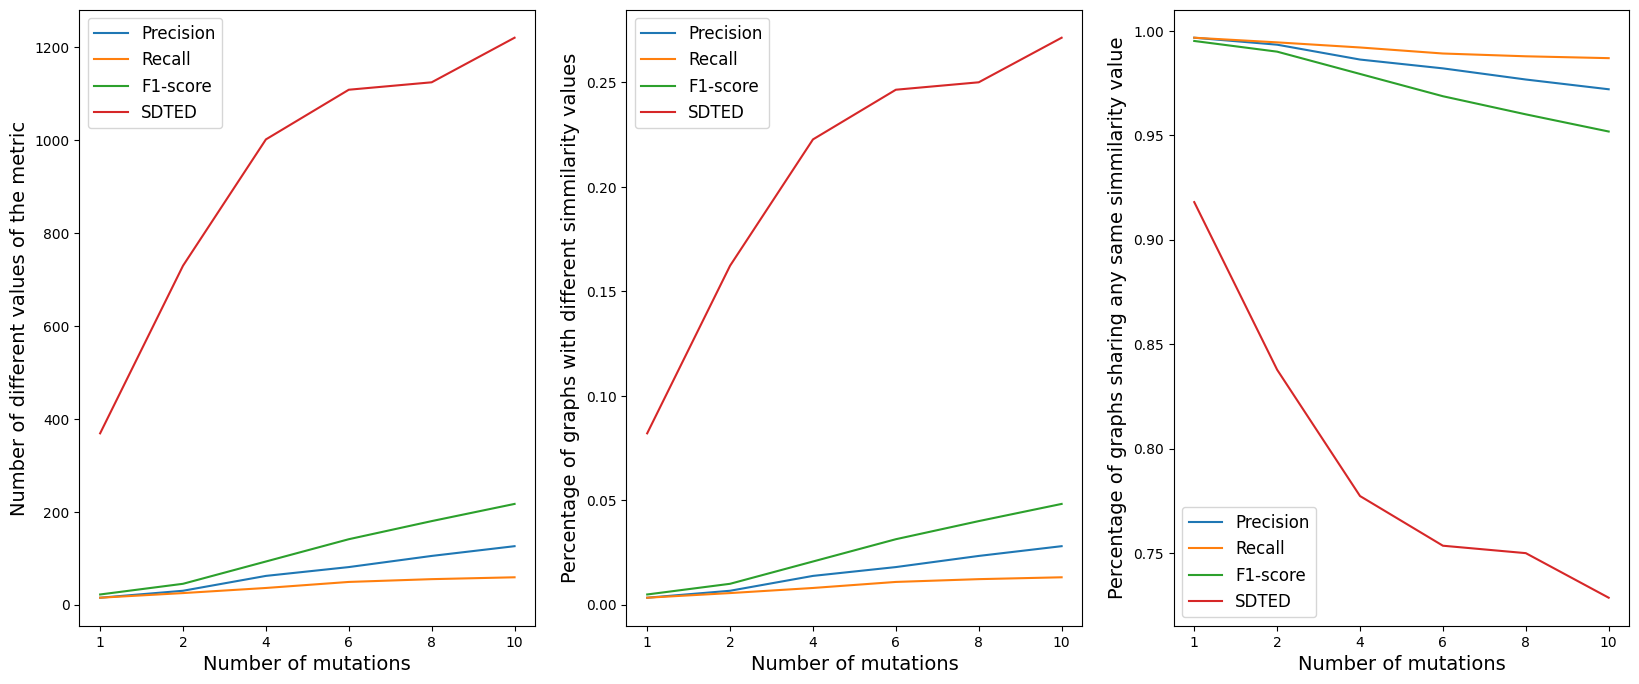

In [55]:

fig, axs = plt.subplots(1, 3, figsize=(20, 8))
for index_ax, ax in enumerate(axs):
    x_prec = []
    y_prec = []
    x_rec = []
    y_rec = []
    x_f1 = []
    y_f1 = []
    x_sdted = []
    y_sdted= []

    factor_norm = NUM_GRAPHS*len(dict_num_values.keys())

    for index, mut in enumerate(list(dict_card_mut.keys())):
        x_prec.append(index)
        x_rec.append(index)
        x_f1.append(index)
        x_sdted.append(index)

        if index_ax == 0:
            y_prec.append(dict_card_mut[mut]["Precision"])
            y_rec.append(dict_card_mut[mut]["Recall"])
            y_f1.append(dict_card_mut[mut]["F1-score"])
            y_sdted.append(dict_card_mut[mut]["SDTED"])
            ax.set_ylabel("Number of different values of the metric", fontsize=14)

        elif index_ax == 1:
            y_prec.append(dict_card_mut[mut]["Precision"]/factor_norm)
            y_rec.append(dict_card_mut[mut]["Recall"]/factor_norm)
            y_f1.append(dict_card_mut[mut]["F1-score"]/factor_norm)
            y_sdted.append(dict_card_mut[mut]["SDTED"]/factor_norm)
            ax.set_ylabel("Percentage of graphs with different simmilarity values", fontsize=14)

        else:
            y_prec.append(1- dict_card_mut[mut]["Precision"]/factor_norm)
            y_rec.append(1- dict_card_mut[mut]["Recall"]/factor_norm)
            y_f1.append(1- dict_card_mut[mut]["F1-score"]/factor_norm)
            y_sdted.append(1-dict_card_mut[mut]["SDTED"]/factor_norm)
            ax.set_ylabel("Percentage of graphs sharing any same simmilarity value", fontsize=14)


    ax.plot(x_prec, y_prec, label = "Precision")
    ax.plot(x_rec, y_rec, label = "Recall")
    ax.plot(x_f1, y_f1, label="F1-score")
    ax.plot(x_sdted, y_sdted, label="SDTED")
    #ax.set_xticks([index for index, _ in enumerate(x_prec)], MUTATIONS_CALCULATE)
    ax.set_xticks([index for index, _ in enumerate(x_prec)])
    ax.set_xticklabels(MUTATIONS_CALCULATE)
    ax.set_xlabel("Number of mutations", fontsize=14)
    #plt.ylabel("Number of different values of the metric", fontsize=14)
    ax.legend( prop={'size': 12})

plt.savefig(f"plots/cardinality_{len(dict_num_values.keys())}.png")

plt.show()

In [12]:
df_long

,graph,timepoint,metric,value
0,0,0,Precision,2
1,0,0,Recall,2
2,0,0,F1-score,3
3,0,0,SDTED,24
4,0,1,Precision,4
...,...,...,...,...
427,17,4,SDTED,84
428,17,5,Precision,27
429,17,5,Recall,7
430,17,5,F1-score,32


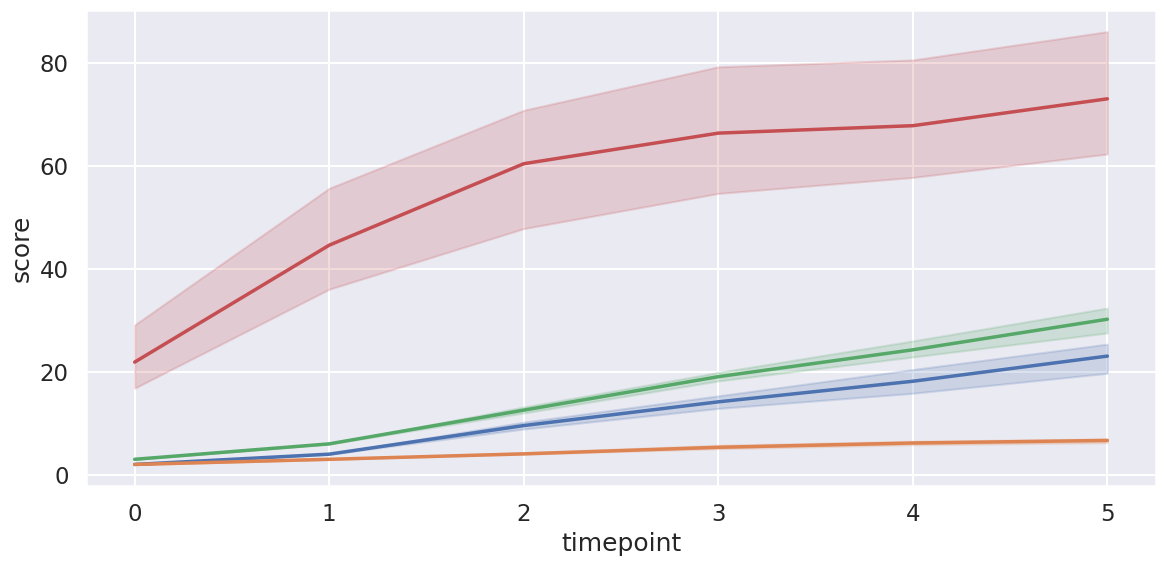

In [28]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# 1. Pasar el diccionario a un DataFrame largo
# ------------------------------------------------------------------
rows = []
for graph_name, mut_dic in dict_num_values.items():
    for t_idx, (mut_label, metrics) in enumerate(mut_dic.items()):
        for metric in ("Precision", "Recall", "F1-score", "SDTED"):
            rows.append({
                "graph"     : graph_name,   # por si luego quieres promediar por gráfico
                "timepoint" : t_idx,        # posición en la serie
                "metric"    : metric,       # Precision / Recall / ...
                "value"     : metrics[metric]
            })

df_long = pd.DataFrame(rows)

# ------------------------------------------------------------------
# 2. Dibujar con Seaborn
# ------------------------------------------------------------------
sns.set(style="darkgrid", context="talk")
plt.figure(figsize=(12,6))

ax = sns.lineplot(
        data      = df_long,
        x         = "timepoint",
        y         = "value",
        hue       = "metric",      # color por métrica
        estimator = "mean",        # promedia si hay varios ensayos
        errorbar  = ("ci", 100),    # banda de confianza ±1 σ aprox.
        linewidth = 2.5,
)

ax.set(xlabel="timepoint", ylabel="score")
#ax.legend(title="")                # quita título del recuadro
ax.legend([],[], frameon=False)
plt.tight_layout()
plt.show()


In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# 1. Pasar de diccionarios anidados → DataFrame ‘largo’
# ------------------------------------------------------------------
records = []
factor_norm = NUM_GRAPHS * len(dict_num_values)

for mut_idx, mut in enumerate(dict_card_mut.keys()):
    vals = dict_card_mut[mut]                # {'Precision': …, 'Recall': …, …}
    for metric, v in vals.items():

        # Escala 1: valor absoluto
        records.append({
            'mutations' : mut_idx,   # (o mut si prefieres el texto)
            'metric'    : metric,
            'kind'      : 'raw',     # etiqueta de faceta
            'value'     : v
        })

        # Escala 2: porcentaje
        records.append({
            'mutations' : mut_idx,
            'metric'    : metric,
            'kind'      : 'percent',
            'value'     : v / factor_norm
        })

        # Escala 3: complemento
        records.append({
            'mutations' : mut_idx,
            'metric'    : metric,
            'kind'      : 'inverse',
            'value'     : 1 - v / factor_norm
        })

df = pd.DataFrame(records)
df['mut_label'] = MUTATIONS_CALCULATE            # para poner las etiquetas bonitas

# ------------------------------------------------------------------
# 2. Dibujar con Seaborn
# ------------------------------------------------------------------
sns.set(style='darkgrid', context='talk')
g = sns.relplot(
        data       = df,
        x          = 'mutations',
        y          = 'value',
        hue        = 'metric',       # color → métrica (Precision/Recall/F1/SDTED)
        style      = 'metric',       # estilo de línea → métrica
        col        = 'kind',         # una columna (faceta) por tipo de escala
        kind       = 'line',
        estimator  = 'mean',         # promedia si hay repeticiones
        errorbar   = ('ci', 68),     # IC 68 %; si no hay repeticiones, no se muestra
        height     = 5,
        aspect     = 1.1,
        facet_kws  = dict(sharey=False)  # cada faceta con su propio eje Y
)

# Etiquetas y títulos
g.set_axis_labels("Número de mutaciones", "Valor de la métrica")
g.set_titles(col_template="{col_name}")   # títulos sencillos: raw / percent / inverse

# Reemplaza los ticks numéricos por tus etiquetas de mutación
for ax in g.axes.flat:
    ax.set_xticks(range(len(MUTATIONS_CALCULATE)))
    ax.set_xticklabels(MUTATIONS_CALCULATE, rotation=45)

g.tight_layout()
#plt.savefig(f"plots/cardinality_{len(dict_num_values.keys())}_seaborn.png", dpi=300)
plt.show()


ValueError: Length of values (6) does not match length of index (72)